Just a dev notebook to develop the algorithm. Will export the finals into a py file for execution. 

In [2]:
# Automatically reload imported modules when their source files change.
%load_ext autoreload
%autoreload 2

In [3]:
# Import the data
import pandas as pd
import numpy as np 
from utils.data_loading import load_participant_details

participant_details = load_participant_details('./raw_data/participant_details.xlsx')

participant = participant_details[0]
path = participant['filename']
data = np.loadtxt(f'./raw_data/{path}', delimiter='\t', skiprows=1, usecols=range(1, 19))

In [4]:
# Sum Humerothoracic rotation
from utils.kinematics.cumulative import calculate_arm_rotations
left_rotation, right_rotation = calculate_arm_rotations(data)
participant['left']['humerothoracic_rotation'] = left_rotation
participant['right']['humerothoracic_rotation'] = right_rotation

print(f"Left arm total rotation: {left_rotation:.2f} radians")
print(f"Right arm total rotation: {right_rotation:.2f} radians")

Left arm total rotation: 354272.47 radians
Right arm total rotation: 359999.97 radians


In [5]:
# Sum motion about each axis
from utils.kinematics.individual_axes import calculate_cumulative_axis_motion
left_axes = calculate_cumulative_axis_motion(data, 'L')
right_axes = calculate_cumulative_axis_motion(data, 'R')
print(f"Left arm cumulative axis motion (radians): {left_axes}")
print(f"Right arm cumulative axis motion (radians): {right_axes}")

ValueError: matrices must be orthonormal rotation matrices

Getting errors about orthonormality. Tells me we might have data drift (or maybe just a bug).

Go through and see how much error is present at each timestamp. Log the values over time. 

```
I = np.eye(3)

for i, R in enumerate(matrices):
    ortho_error = np.linalg.norm(R.T @ R - I)
    det_error = np.abs(np.linalg.det(R) - 1)

    if ortho_error > 1e-6 or det_error > 1e-6:
        print(i, ortho_error, det_error)
```

| Error        | Meaning                      |
| ------------ | ---------------------------- |
| ~1e-12       | fine (floating point noise)  |
| 1e-6 to 1e-3 | mild drift / sensor noise    |
| >1e-3        | serious corruption           |
| >> 1         | not a rotation matrix at all |


Make decisions from there.

In [27]:
import os 
from scipy import stats
from utils.kinematics.general_helpers import create_rotation_matrices

# set current directory
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Build rotation matrices
left_matrices = create_rotation_matrices(data, 'L')

# determine how much the matrices deviate from being orthonormal
def calculate_variance_from_orthonormality(matrices):
    data_array = np.asarray(matrices, dtype=np.float64)
    identity = np.eye(3, dtype=np.float64)
    ortho_error_matrices = (
        np.transpose(data_array, axes=(0, 2, 1))
        @ data_array
        - identity
    )
    return np.linalg.norm(ortho_error_matrices, axis=(1, 2))

variance = calculate_variance_from_orthonormality(left_matrices)

summary = stats.describe(variance)
labels = ["Number of observations", "Min-Max", "Mean", "Variance", "Skewness", "Kurtosis"]
for label, value in zip(labels, summary):
    print(f"{label:<25} : {value}")

Number of observations    : 404800
Min-Max                   : (1.1931257268181066e-05, 1.4005357520433481)
Mean                      : 0.000616359247373572
Variance                  : 2.1477096900688504e-05
Skewness                  : 119.32194121150413
Kurtosis                  : 27734.27044386857


<Axes: >

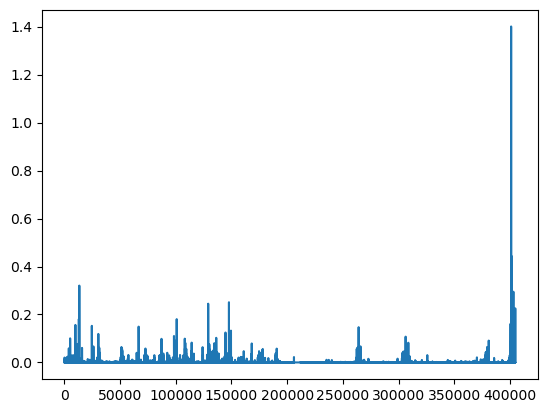

In [ ]:
import seaborn as sns
sns.lineplot(x=range(len(variance)), y=variance)
print(np.describe(variance))

In [ ]:
# extract the filename, arm, and handedness
# for each arm
    # sum humerothoracic rotation
    # sum glenoohumeral rotation (later)
    # bin %time spent in each region of elevation and PoE